# **Q1. MCMC estimation of π**

#### **(a) Show numerically that the points generated are uniform in the square.**

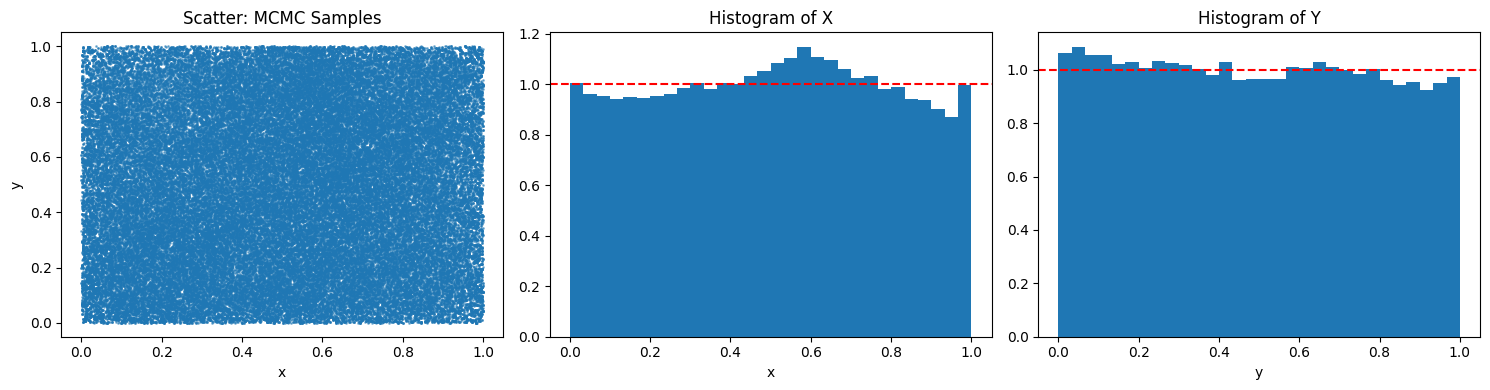

In [124]:
import numpy as np
import matplotlib.pyplot as plt

nsteps = 100000
h = 0.1
x, y = 0.5, 0.5
samples = []
accepted = 0

# The PDF of the joint uniform law
def pdf_target(x, y):
    if 0 <= x <= 1 and 0 <= y <= 1:
        return 1.0
    else:
        return 0.0

#  Metropolis Random Walk
for i in range(nsteps):
    # The symmetric displacement
    x_prop = x + np.random.uniform(-h, h)
    y_prop = y + np.random.uniform(-h, h)

    # Acceptance probability
    alpha = min(1, pdf_target(x_prop, y_prop) / pdf_target(x, y))

    # Generate uniform random number
    r = np.random.rand()

    if r < alpha:
        x, y = x_prop, y_prop
        accepted += 1

    samples.append([x, y])

samples = np.array(samples)

plt.figure(figsize=(15,4))

# Scatter plot
plt.subplot(1,3,1)
plt.scatter(samples[:,0], samples[:,1], s=1, alpha=0.5)
plt.title("Scatter: MCMC Samples")
plt.xlabel("x")
plt.ylabel("y")

# Histogram of X
plt.subplot(1,3,2)
plt.axhline(y=1, color='r', linestyle='--', label='y=1')
plt.hist(samples[:,0], bins=30, density=True)
plt.title("Histogram of X")
plt.xlabel("x")

#  Histogram of Y
plt.subplot(1,3,3)
plt.axhline(y=1, color='r', linestyle='--', label='y=1')
plt.hist(samples[:,1], bins=30, density=True)
plt.title("Histogram of Y")
plt.xlabel("y")

plt.tight_layout()
plt.show()



#### (b) **Let's show numerically that your estimator of  converges to the correct value.**

Acceptance ratio: 0.90279


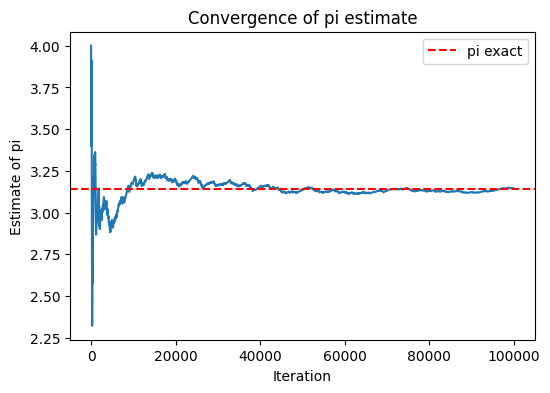

Final pi estimate: 3.14616
Exact pi = 3.141592653589793


In [125]:
# Acceptance ratio
print("Acceptance ratio:", accepted / nsteps)
# To find samples in the circle
inside_circle = (samples[:,0]**2 + samples[:,1]**2 <= 1)
pi_est_running = 4 * np.cumsum(inside_circle) / np.arange(1, nsteps+1)

plt.figure(figsize=(6,4))
plt.plot(pi_est_running)
plt.axhline(np.pi, color='r', linestyle='--', label="pi exact")
plt.title("Convergence of pi estimate")
plt.xlabel("Iteration")
plt.ylabel("Estimate of pi")
plt.legend()
plt.show()

print("Final pi estimate:", float(pi_est_running[-1]))
print("Exact pi =", float(np.pi))


#### **(c) Can we construct error bars for this estimator the way we did in CW1?**

No, we can't construct the error bars, because unlike in the CW1 where we assumed independent samples for the Monte Carlo estimate, here we use MCMC with a random walk.

In MCMC, each sample depends on the previous one, which introduces autocorrelation in the chain.

Because of this correlation, the standard method for estimating the error underestimates the true uncertainty, so the resulting error bars would not be reliable.


# **Q2. Gaussian mixture.**

Let's use the Metropolis algorithm to sample from the following Gaussian mixture:
$$
p(x) = a_1 \, p_1(x) + a_2 \, p_2(x),
$$

where:  
 $$p_1(x) = \mathcal{N}(20, 100) \quad p_2(x) = \mathcal{N}(20, 100)$$  
and $$a_1 = 0.3, a_2 = 0.7$$

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# The target probability distribution function of the Gaussian Mixture
def pdf_gaussian_mixture(x, mu1, mu2, sigma1, sigma2):
    p1 = (1/(sigma1*np.sqrt(2*np.pi))) * np.exp(-(x-mu1)**2/(2*sigma1**2))
    p2 = (1/(sigma2*np.sqrt(2*np.pi))) * np.exp(-(x-mu2)**2/(2*sigma2**2))
    return 0.3 * p1 + 0.7 * p2

# Parameters
proposal_std = 1
nsteps = 10000
mu1_target = 20
mu2_target = -20
sigma_target = 10

# Metropolis Random Walk
def metropolis_r_walk(nsteps, proposal_sd):
    samples = []
    x_current = 20
    accepted_count = 0

    for i in range(nsteps):
        x_prop = x_current + np.random.normal(0,proposal_sd)
        target_pdf_x_prop = pdf_gaussian_mixture(x_prop, mu1_target, mu2_target, sigma_target, sigma_target)
        target_pdf_x_current = pdf_gaussian_mixture(x_current, mu1_target, mu2_target, sigma_target, sigma_target)

        # to take the min bewteen 1 and the ratio target_pdf_x_prop and target_pdf_x_current
        if target_pdf_x_current == 0:
            alpha = 1.0 if target_pdf_x_prop > 0 else 0.0 # because target_pdf_x_current can take value 0
        else:
            alpha = min(1.0, target_pdf_x_prop / target_pdf_x_current)

        # Generation of uniform random number for acceptance
        r = np.random.rand()

        if r < alpha:
            x_current = x_prop
            accepted_count += 1
        samples.append(x_current)

    return np.array(samples), accepted_count



 The acceptance for the value 1 of sigma is 0.9678
Fraction of samples in the left mode (sigma = 1): 0.7123 (knowing a = 0.7)
Fraction of samples in the right mode (sigma = 1): 0.2877 (knowing b = 0.3)  

 The acceptance for the value 500 of sigma is 0.0465
Fraction of samples in the left mode (sigma = 500): 0.6797 (knowing a = 0.7)
Fraction of samples in the right mode (sigma = 500): 0.3203 (knowing b = 0.3)  

 The acceptance for the value 8 of sigma is 0.7839
Fraction of samples in the left mode (sigma = 8): 0.6867 (knowing a = 0.7)
Fraction of samples in the right mode (sigma = 8): 0.3133 (knowing b = 0.3)  



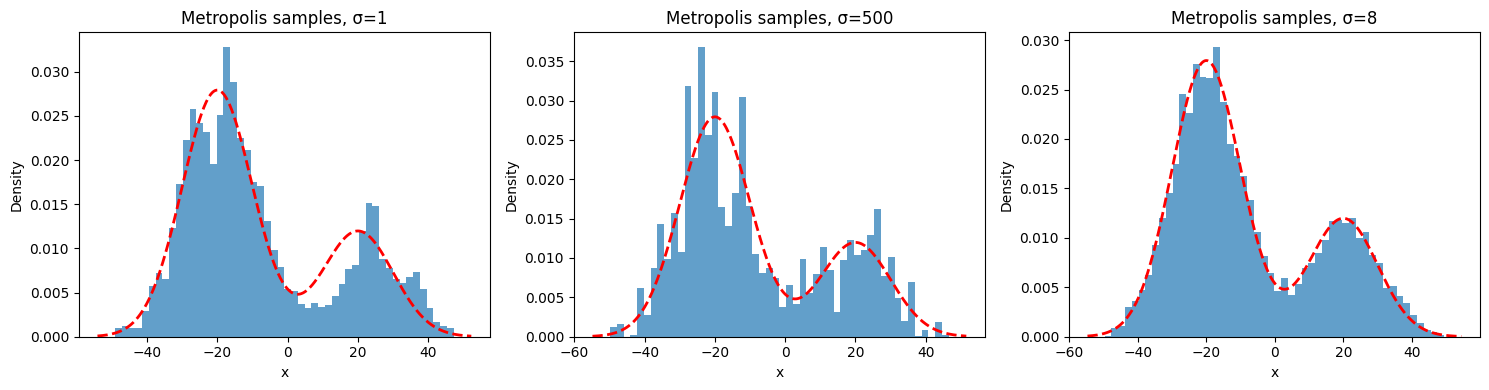

In [127]:
sigmas = [1, 500, 8]
plt.figure(figsize=(15,4))

for i, sigma in enumerate(sigmas):
    samples, accepted_count = metropolis_r_walk(nsteps, sigma)
    print(f" The acceptance for the value {sigma} of sigma is {accepted_count/nsteps}")
    #  THis is to more explain the comments
    frac_left = np.mean(samples < 0)
    frac_right = np.mean(samples >= 0)
    print(f"Fraction of samples in the left mode (sigma = {sigma}): {frac_left} (knowing a = 0.7)")
    print(f"Fraction of samples in the right mode (sigma = {sigma}): {frac_right} (knowing b = 0.3)  \n")
    x_values = np.linspace(samples.min() - 5, samples.max() + 5, 500)
    theoretical_pdf = pdf_gaussian_mixture(x_values, mu1_target, mu2_target, sigma_target, sigma_target)
    plt.subplot(1, 3, i+1)
    plt.plot(x_values, theoretical_pdf, color='red', linestyle='--', linewidth=2, label='Theoretical PDF')
    plt.hist(samples, bins=50, density=True, alpha= 0.7)
    plt.title(f'Metropolis samples, σ={sigma}')
    plt.xlabel('x')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

**Discussion**

 **For σ = 1**

* Acceptance rate ≈ 0.97 (very high)
* Observed approximate fractions: not stable, sometimes good, sometimes the opposite.

The fractions (left and right) are very unstable from one run to the next.

We can say that the chain often gets stuck in one mode and rarely switches to the other. The displacement is too small for a bimodal mixture, which may explain the unstable ratios.

 **For σ = 500**

* Acceptance rate ≈ 0.044–0.045 (very low)
* Observed approximate fractions: left ≈ 0.69 / right ≈ 0.31
* The fractions are correct and relatively stable despite the very low acceptance rate.

So most of the proposals are rejected by the acceptance condition, each acceptance involves a huge jump (often from one mode to another)

 **For σ = 8**

* Acceptance rate ≈ 0.79
* Observed approximate fractions: left ≈ 0.67 and right ≈ 0.33

We notice proportions that are quite stable and close to the true weights.

Here, we note that the standard deviation of the proposition in Metropolis is very close to 10, the standard deviation of p1 and p2.

We can say there are efficient exploration, frequent transitions between modes

and so it,s  a good compromise.

**Conclusion**

We can conclude that when the standard deviation of the Gaussian shifts is close to 10 (case σ = 8), we obtain the best results, with efficient exploration and stable proportions.

When σ is too large, the proposed jumps are excessive, and most points are rejected by the acceptance condition. When σ is too small, the displacements are too small and the chain often remains stuck in a mode, resulting in unstable fractions.

#**Q3. Gaussian mixture.**

### (a) **Let's generate 50 data points from this model using the true parameters**:  




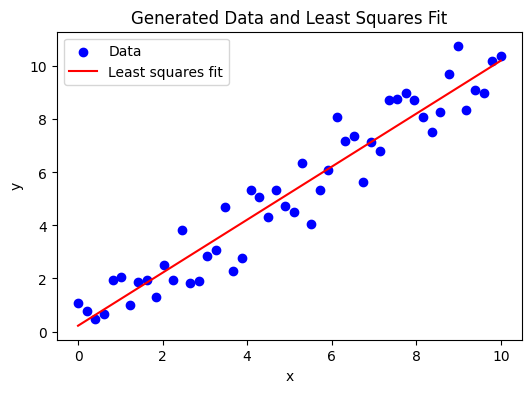

Least squares fit: a = 0.999, b = 0.219


In [128]:
# The true parameters
a_true = 1
b_true = 0
sigma_true = 1
n_points = 50

# Generate x values, let's chose between 0 and 10
x = np.linspace(0, 10, n_points)

# Gaussian noise z
z = np.random.normal(0, sigma_true, size=n_points)

# So y values
y = a_true * x + b_true + z

# Least squares fit on data
coeffs = np.polyfit(x, y, 1)
y_fit = np.polyval(coeffs, x)

# Scatter and  least squares fit plots
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_fit, color='red', label='Least squares fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data and Least Squares Fit')
plt.legend()
plt.show()

print(f"Least squares fit: a = {coeffs[0]:.3f}, b = {coeffs[1]:.3f}")

### **(b) Let's find the expression of the Likelihood and Posterior**



We consider the linear Gaussian model:

$$
y_i = a x_i + b + \sigma z_i, \quad z_i \sim \mathcal{N}(0, 1), \quad i=1,\dots,N
$$

with parameters $\theta = (a, b, \sigma)$.



 **Likelihood $$p(D \mid \theta)$$**

The likelihood of the data $D = \{(x_i, y_i)\}_{i=1}^N$ is the product of the individual Gaussian densities, that is:
$$
p(D \mid \theta) = \prod_{i=1}^{N} P(y_i \mid \theta)
$$


$$z_i \sim \mathcal{N}(0, 1) \quad \text{so we have} \quad y_i  \sim \mathcal N(a x_i + b,\ \sigma^2) \quad \text{knowing} \quad \theta  $$
Then,
$$
\boxed{p(D \mid \theta) = \prod_{i=1}^{N} \frac{1}{\sqrt{2 \pi} \sigma}
\exp\Bigg[-\frac{(y_i - (a x_i + b))^2}{2 \sigma^2}\Bigg]}
$$
With a requirement on σ which should be positive.

 The expression of priors are:

Let's assume following independent Gaussian priors for the parameters:

$$
a \sim \mathcal{N}(\mu_a, \sigma_a^2), \quad
b \sim \mathcal{N}(\mu_b, \sigma_b^2), \quad
\sigma \sim \mathcal{N}(\mu_\sigma, \sigma_\sigma^2)
$$

Then the prior is:

$$
p(\theta) = p(a) \, p(b) \, p(\sigma)
$$

with each term:

$$
p(a) = \frac{1}{\sqrt{2 \pi} \sigma_a} \exp\Big[-\frac{(a - \mu_a)^2}{2 \sigma_a^2}\Big], \quad
p(b) = \frac{1}{\sqrt{2 \pi} \sigma_b} \exp\Big[-\frac{(b - \mu_b)^2}{2 \sigma_b^2}\Big], \quad
p(\sigma) = \frac{1}{\sqrt{2 \pi} \sigma_\sigma} \exp\Big[-\frac{(\sigma - \mu_\sigma)^2}{2 \sigma_\sigma^2}\Big]
$$



  **Posterior**

By Bayes' formula:

$$
p(\theta \mid D) = \frac{p(D \mid \theta) \, p(\theta)}{p(D)}
$$

Since the evidence $p(D)$ is generally unknown, we write:

$$
p(\theta \mid D) \propto p(D \mid \theta) \, p(a) \, p(b) \, p(\sigma)
$$

$$
\boxed{p(\theta \mid D) \propto \prod_{i=1}^{N} \frac{1}{\sqrt{2 \pi} \sigma}
\exp\Bigg[-\frac{(y_i - (a x_i + b))^2}{2 \sigma^2} \Bigg] p(a) \, p(b) \, p(\sigma)}
$$



### (c) **Let's construct an MCMC algorithm for sampling the posterior based on the unnormalised expression of this distribution found in (b).**

Let's apply the logarithm to the posterior expression to simplify the code. We will use the exponentielle function to obtain the real expression of the posterior.

$$
\log p(\theta \mid D) \propto
\sum_{i=1}^{N} \log \Bigg[ \exp\Bigg(-\frac{(y_i - (a x_i + b))^2}{2 \sigma^2} \Bigg) \Bigg] + N \log \frac{1}{\sqrt{2 \pi} \sigma}
+ \log p(a) + \log p(b) + \log p(\sigma)
$$

$$
\log p(\theta \mid D) \propto
\sum_{i=1}^{N} \Bigg(-\frac{(y_i - (a x_i + b))^2}{2 \sigma^2} \Bigg) - N \log (\sqrt{2 \pi})- N \log (\sigma)
+ \log p(a) + \log p(b) + \log p(\sigma)
$$

Because appears $(\sqrt{2\pi})^N$ in both numerator and denominator, we can omit $- N\log (\sqrt{2 \pi})$ and $\log (\sqrt{2 \pi})$ of p(a), p(b) and $p(\sigma)$ in the algorithm. we can omit the $\log (\sigma)$ in the last ones because the log-likelihood already contains the it.

In [129]:
# The log-posterior (unnormalized)
def log_posterior(a, b, sigma, x, y, hyperparams):
    if sigma <= 0:
        return -np.inf
    # the log likelihood
    resid = y - (a*x + b)
    log_likehood = -0.5*np.sum(resid**2) / (sigma**2) - len(y)*np.log(sigma)

    # Gaussian priors p(a), p(b) and p(sigma)
    log_p = -0.5*((a-hyperparams['mu_a'])/hyperparams['sd_a'])**2
    log_p += -0.5*((b-hyperparams['mu_b'])/hyperparams['sd_b'])**2
    log_p += -0.5*((sigma-hyperparams['mu_sigma'])/hyperparams['sd_sigma'])**2

    return log_likehood + log_p

In [130]:
def metropolis_mcmc_linear(x, y, nsteps, proposal_sd, hyperparams):
  # Initial values
  a_current, b_current, sigma_current = 0.0, 0.5, 0.0
  samples =[]
  accepted = 0

  for itt in range(nsteps):
    a_prop = a_current + np.random.normal(0, proposal_sd['a'])
    b_prop = b_current + np.random.normal(0, proposal_sd['b'])
    sigma_prop = sigma_current + np.random.normal(0, proposal_sd['sigma'])
    # Because sigma_prop is the standard deviation of the Gaussian in likehoods
    if sigma_prop <= 0:
        samples.append([a_current, b_current, sigma_current])
        continue
    else:
        log_post_current = log_posterior(a_current, b_current, sigma_current, x, y, hyperparams)
        log_post_prop    = log_posterior(a_prop, b_prop, sigma_prop, x, y, hyperparams)
        log_alpha = min(0, log_post_prop - log_post_current) # Because log(1) = 0

        if np.log(np.random.rand()) < log_alpha:
            a_current, b_current, sigma_current = a_prop, b_prop, sigma_prop
            accepted += 1
    samples.append([a_current, b_current, sigma_current])
  return np.array(samples), accepted / nsteps

In [133]:
nsteps = 200000

# to track and look for a acceptance around 0.5
target_accept = 0.50
tol = 0.05
max_iter = 20

# small proposal sd for a,b and sigma
proposal_sd = {'a': 0.05, 'b': 0.05, 'sigma': 0.02}

# Hyperparameters for priors
hyperparams = {
    'mu_a': 0.8, 'sd_a': 2.0,
    'mu_b': 0.1, 'sd_b': 2.0,
    'mu_sigma': 0.8, 'sd_sigma': 2.0
}
# To find a acceptance ratio close of 0.5
for i in range(max_iter):

    print(f"Acceptance ratio checking {i+1}\n ")
    samples, acc_ratio = metropolis_mcmc_linear(x, y, nsteps, proposal_sd, hyperparams)

    print("Acceptance ratio:", acc_ratio)

    # Stop when acceptance ratio is close of 0.5
    if abs(acc_ratio - target_accept) < tol:
        print("Acceptance ratio is close of 0.5")
        break

    # Otherwise adjust proposal_sd automatically
    if acc_ratio < target_accept:
        # to decrease proposal_sd
        factor = 0.8
    else:
        # to increase proposal_sd
        factor = 1.2

    proposal_sd['a'] *= factor
    proposal_sd['b'] *= factor
    proposal_sd['sigma'] *= factor
    print("Acceptance ratio:", acc_ratio)
    print(f"Acceptance ratio isn't close of 0.5 after {i+1} itteration")

samples, acc_ratio = metropolis_mcmc_linear(x, y, nsteps, proposal_sd, hyperparams)

burn_in = int(0.2 * nsteps)   # to discard first 20%
thin = 10                     # to keep every 10th sample
post = samples[burn_in::thin] # new samples
a_samps = post[:,0]
b_samps = post[:,1]
sigma_samps = post[:,2]

a_mean = np.mean(a_samps)
b_mean = np.mean(b_samps)
sigma_mean = np.mean(sigma_samps)
# Find the most probable values of the parameters
logposts_all = np.array([log_posterior(a,b,sigma,x,y, hyperparams) for (a,b,sigma) in post])
map_idx = np.argmax(logposts_all)
map_a, map_b, map_sigma = post[map_idx]
print(f"Mean estimate (a,b,sigma) ≈ ({a_mean:.4f}, {b_mean:.4f}, {sigma_mean:.4f})")
print(f"MAP estimate (a,b,sigma) ≈ ({map_a:.4f}, {map_b:.4f}, {map_sigma:.4f})")


Acceptance ratio checking 1
 
Acceptance ratio: 0.432995
Acceptance ratio: 0.432995
Acceptance ratio isn't close of 0.5 after 1 itteration
Acceptance ratio checking 2
 
Acceptance ratio: 0.5037
Acceptance ratio is close of 0.5
Mean estimate (a,b,sigma) ≈ (1.0006, 0.2109, 0.8893)
MAP estimate (a,b,sigma) ≈ (1.0004, 0.2126, 0.8415)


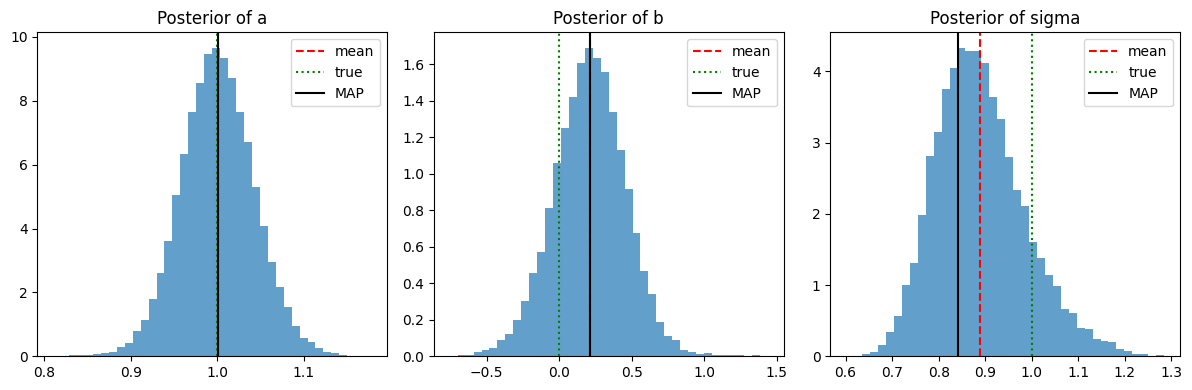

In [134]:
# Visualization
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(a_samps, bins=40, density=True, alpha=0.7)
plt.axvline(a_mean, color='red', linestyle='--', label='mean')
plt.axvline(a_true, color='green', linestyle=':', label='true')
plt.axvline(map_a, color='black', linestyle='-', label='MAP')
plt.title('Posterior of a')
plt.legend()

plt.subplot(1,3,2)
plt.hist(b_samps, bins=40, density=True, alpha=0.7)
plt.axvline(b_mean, color='red', linestyle='--', label='mean')
plt.axvline(b_true, color='green', linestyle=':', label='true')
plt.axvline(map_b, color='black', linestyle='-', label='MAP')
plt.title('Posterior of b')
plt.legend()

plt.subplot(1,3,3)
plt.hist(sigma_samps, bins=40, density=True, alpha=0.7)
plt.axvline(sigma_mean, color='red', linestyle='--', label='mean')
plt.axvline(sigma_true, color='green', linestyle=':', label='true')
plt.axvline(map_sigma, color='black', linestyle='-', label='MAP')
plt.title('Posterior of sigma')
plt.legend()

plt.tight_layout()
plt.show()
